In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

from itertools import product
from typing import Union
from tqdm.notebook import tqdm

In [53]:
macro_data = sm.datasets.macrodata.load_pandas().data

In [54]:
macro_data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [55]:
exog_vars = macro_data.iloc[:,3:8]
exog_vars

,realcons,realinv,realgovt,realdpi,cpi
0,1707.4,286.898,470.045,1886.9,28.980
1,1733.7,310.859,481.301,1919.7,29.150
2,1751.8,289.226,491.260,1916.4,29.350
3,1753.7,299.356,484.052,1931.3,29.370
4,1770.5,331.722,462.199,1955.5,29.540
...,...,...,...,...,...
198,9267.7,1990.693,991.551,9838.3,216.889
199,9195.3,1857.661,1007.273,9920.4,212.174
200,9209.2,1558.494,996.287,9926.4,212.671
201,9189.0,1456.678,1023.528,10077.5,214.469


In [ ]:
# gdp = gdp.rename(columns={'cpi':'consumer price indice'})

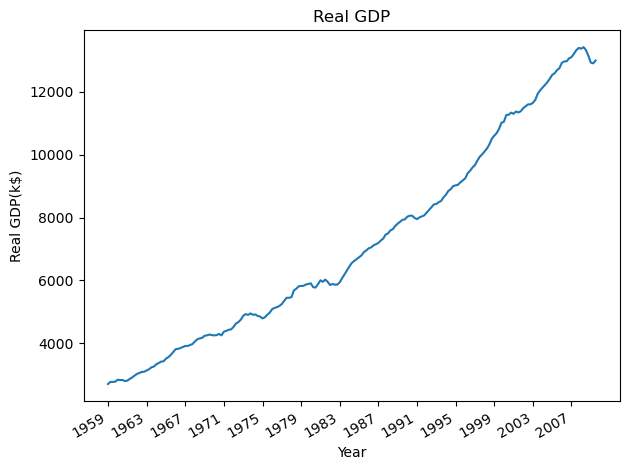

In [70]:
fig, ax = plt.subplots()

ax.plot(macro_data['realgdp'])
ax.set_xlabel('Year')
ax.set_ylabel('Real GDP(k$)')

plt.xticks(
    np.arange(0,208,16),
    np.arange(1959,2010,4)
)

plt.title("Real GDP")
fig.autofmt_xdate()
plt.tight_layout()

In [47]:
print(f'Shape : {gdp.shape}')

Shape : (203, 14)


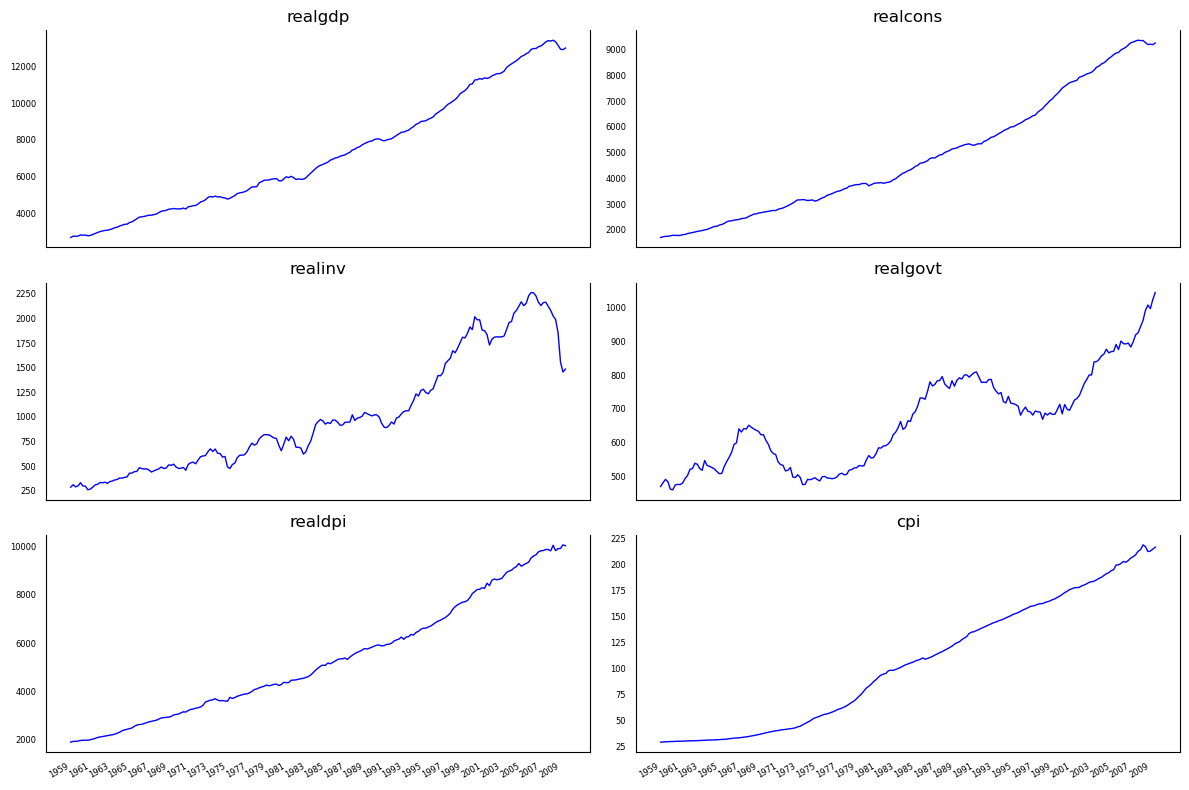

In [74]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,8))

for i, ax in enumerate(axes.flatten()[:6]):
    data = macro_data[macro_data.columns[i+2]] #gdp starts at position 2 skipping year and Q

    ax.plot(data, color='blue', linewidth=1)
    ax.set_title(macro_data.columns[i+2])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_alpha(0)
    ax.tick_params(labelsize=6)

    plt.setp(axes, xticks=np.arange(0,208,8), xticklabels=np.arange(1959,2010,2))
    fig.autofmt_xdate()
    plt.tight_layout()

## Building and forecasting

In [75]:
target = macro_data['realgdp']

In [76]:
def adf_test(serie):
    test = adfuller(serie)

    print(f"stat: {test[0]}")
    print(f"p-value: {test[1]}")

    return 'not stationnary' if test[1] > 0.05 else 'stationnary'

In [77]:
adf_test(target)

stat: 1.750462796764713
p-value: 0.9982455372335032


'not stationnary'

In [78]:
target_diff = np.diff(target)
adf_test(target_diff)

stat: -6.305695561658099
p-value: 3.327882187668351e-08


'stationnary'

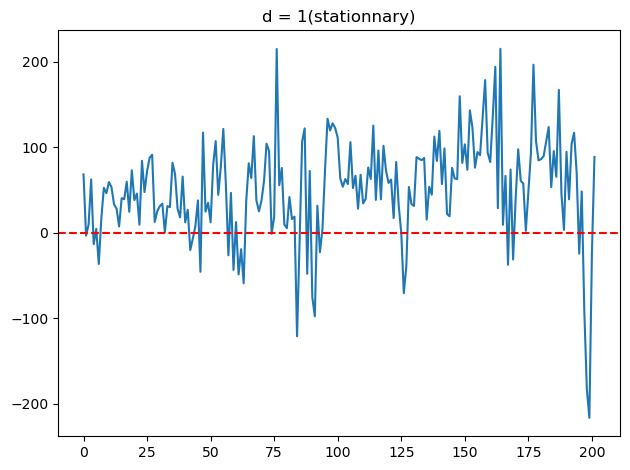

In [79]:
fig,ax = plt.subplots()

ax.plot(target_diff)
ax.axhline(y=0, color='red', linestyle='--')
plt.title('d = 1(stationnary)')
plt.tight_layout()

In [81]:
d = 1
D = 0
s = 4

p = range(0,4,1)
q = range(0,4,1)
P = range(0,4,1)
Q = range(0,4,1)

orders = list(product(p,q,P,Q))

In [88]:
orders

[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 0, 2),
 (0, 0, 0, 3),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 0, 1, 2),
 (0, 0, 1, 3),
 (0, 0, 2, 0),
 (0, 0, 2, 1),
 (0, 0, 2, 2),
 (0, 0, 2, 3),
 (0, 0, 3, 0),
 (0, 0, 3, 1),
 (0, 0, 3, 2),
 (0, 0, 3, 3),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 0, 2),
 (0, 1, 0, 3),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (0, 1, 1, 2),
 (0, 1, 1, 3),
 (0, 1, 2, 0),
 (0, 1, 2, 1),
 (0, 1, 2, 2),
 (0, 1, 2, 3),
 (0, 1, 3, 0),
 (0, 1, 3, 1),
 (0, 1, 3, 2),
 (0, 1, 3, 3),
 (0, 2, 0, 0),
 (0, 2, 0, 1),
 (0, 2, 0, 2),
 (0, 2, 0, 3),
 (0, 2, 1, 0),
 (0, 2, 1, 1),
 (0, 2, 1, 2),
 (0, 2, 1, 3),
 (0, 2, 2, 0),
 (0, 2, 2, 1),
 (0, 2, 2, 2),
 (0, 2, 2, 3),
 (0, 2, 3, 0),
 (0, 2, 3, 1),
 (0, 2, 3, 2),
 (0, 2, 3, 3),
 (0, 3, 0, 0),
 (0, 3, 0, 1),
 (0, 3, 0, 2),
 (0, 3, 0, 3),
 (0, 3, 1, 0),
 (0, 3, 1, 1),
 (0, 3, 1, 2),
 (0, 3, 1, 3),
 (0, 3, 2, 0),
 (0, 3, 2, 1),
 (0, 3, 2, 2),
 (0, 3, 2, 3),
 (0, 3, 3, 0),
 (0, 3, 3, 1),
 (0, 3, 3, 2),
 (0, 3, 3, 3),
 (1, 0, 0, 0),
 (1, 0, 0, 1),
 (1, 0, 0,

In [100]:
def OptimizedSARIMAX(endog:Union[pd.Series, list], exog:Union[pd.Series, list], orders_list:list, d:int,D:int,s:int) -> pd.DataFrame:
    results = []

    for order in tqdm(orders_list):
        try:
            model =  SARIMAX(endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        aic = model.aic
        results.append([order, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [92]:
target_train = target[:200]
exog_train = exog_vars[:200]

In [93]:
exog_train

,realcons,realinv,realgovt,realdpi,cpi
0,1707.4,286.898,470.045,1886.9,28.980
1,1733.7,310.859,481.301,1919.7,29.150
2,1751.8,289.226,491.260,1916.4,29.350
3,1753.7,299.356,484.052,1931.3,29.370
4,1770.5,331.722,462.199,1955.5,29.540
...,...,...,...,...,...
195,9363.6,2123.426,925.110,9886.2,212.495
196,9349.6,2082.886,943.372,9826.8,213.997
197,9351.0,2026.518,961.280,10059.0,218.610
198,9267.7,1990.693,991.551,9838.3,216.889


In [94]:
target_train

0       2710.349
1       2778.801
2       2775.488
3       2785.204
4       2847.699
         ...    
195    13391.249
196    13366.865
197    13415.266
198    13324.600
199    13141.920
Name: realgdp, Length: 200, dtype: float64

In [101]:
result_df = OptimizedSARIMAX(target_train, exog_train, orders, d, D, s)

  0%|          | 0/256 [00:00<?, ?it/s]

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

In [102]:
result_df

,"(p,q,P,Q)",AIC
0,"(3, 3, 0, 0)",1742.822410
1,"(3, 3, 1, 0)",1744.965814
2,"(3, 3, 0, 1)",1744.998578
3,"(2, 2, 0, 0)",1745.444453
4,"(2, 2, 0, 1)",1746.085222
...,...,...
251,"(0, 2, 0, 0)",1761.579044
252,"(0, 3, 0, 0)",1762.317095
253,"(0, 0, 0, 0)",1764.754980
254,"(1, 0, 0, 0)",1765.379412


## SARIMAX(3,1,3)(0,0,0) ==> ARIMAX(3,1,3)

In [104]:
Model = SARIMAX(target_train, exog_train, order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
result = Model.fit(disp=False)

result.summary()

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                realgdp   No. Observations:                  200
Model:               SARIMAX(3, 1, 3)   Log Likelihood                -859.411
Date:                Sun, 30 Aug 2026   AIC                           1742.822
Time:                        19:32:00   BIC                           1782.342
Sample:                             0   HQIC                          1758.817
                                - 200                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9684      0.045     21.604      0.000       0.881       1.056
realinv        1.0136      0.033     30.824      0.000       0.949       1.078
realgovt       0.7286      0.127      5.742      0.000       0.480       0.977
realdpi        0.0096      0.025      0.385      0.701      -0.039       0.058
cpi            5.8678      1.305      4.496      0.000       3.310       8.426
ar.L1          1.0651      0.397      2.682      0.007       0.287       1.844
ar.L2          0.4919      0.699      0.704      0.482      -0.878       1.862
ar.L3         -0.6744      0.336     -2.008      0.045      -1.333      -0.016
ma.L1         -1.1040      0.429     -2.574      0.010      -1.945      -0.263
ma.L2         -0.3223      0.765     -0.421      0.674      -1.822       1.178
ma.L3          0.6477      0.402      1.610      0.107      -0.141       1.436
sigma2       330.1074     30.559     10.802      0.000     270.212     390.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                13.35
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               3.56   Skew:                             0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

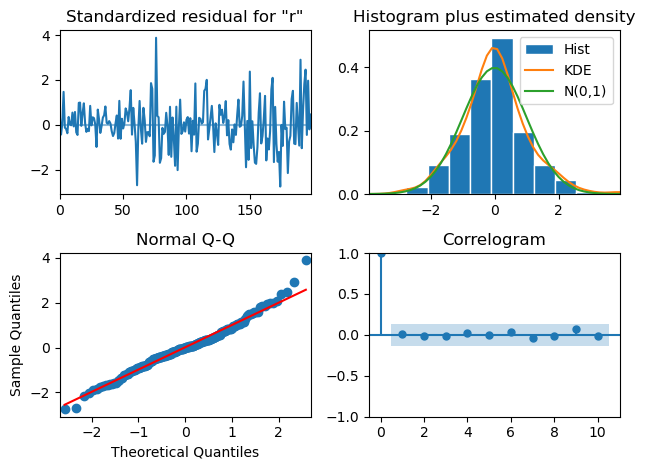

In [107]:
result.plot_diagnostics()
plt.tight_layout()

In [108]:
from statsmodels.stats.diagnostic import acorr_ljungbox
pvalues = acorr_ljungbox(result.resid)
pvalues

,lb_stat,lb_pvalue
1,0.087061,0.767948
2,0.208254,0.901111
3,0.211966,0.975635
4,1.212413,0.876051
5,1.213940,0.943533
6,1.236078,0.975065
7,1.433787,0.984514
8,1.444447,0.993592
9,1.816971,0.994042
10,1.822353,0.997529


p-vals > 5% ~> H0 not rejected ~> errors are independant and normal

In [ ]:
def rolling_forecast(endog:Union[pd.Series, list], exog:Union[pd.Series, list], train_len:int, horizon:int, window:int, method:str) -> list:
    total_len = train_len + horizon

    if method == 'last':
        pred_lv = []
        for i in range(train_len, total_len, window):
            last = endog[:i].iloc[-1]
            pred_lv.extend(last for _ in range(window))
        return pred_lv

    elif method == 'mean':
        mean_pred = []
        for i in range(train_len, total_len, window):
            mean = np.mean(endog[:i])
            mean_pred.extend(mean for _ in range(window))
        return mean_pred
        
    elif method == 'SARIMAX':
        SRX_pred = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(endog[:i], exog[:i], order=(3,1,3), seasonal_order=(0,0,0,4), simple_differencing=False)
            result = model.fit(disp=False)
            predictions = result.get_prediction(exog=exog)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            SRX_pred.extend(oos_pred)
        return SRX_pred

In [ ]:
#2008-2009
target_train = target[:196]
target_test = target[196:]

pred_df = pd.DataFrame({'actual':target_test})

In [131]:
TRAIN_LEN = len(target_train)
HORIZON = len(target_test)

WINDOW = 1

LV = rolling_forecast(target, exog_vars, TRAIN_LEN, HORIZON, WINDOW, 'last')
MEAN = rolling_forecast(target, exog_vars, TRAIN_LEN, HORIZON, WINDOW, 'mean')
SRMX = rolling_forecast(target, exog_vars, TRAIN_LEN, HORIZON, WINDOW, 'SARIMAX')

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

In [132]:
pred_df['last_value'] = LV
pred_df['mean_pred'] = MEAN
pred_df['SARIMAX_pred'] = SRMX

In [133]:
pred_df

,actual,last_value,mean_pred,SARIMAX_pred
196,13366.865,13391.249,7009.346888,13344.064035
197,13415.266,13366.865,7041.618553,13373.512285
198,13324.600,13415.266,7073.808692,13378.806183
199,13141.920,13324.600,7105.219704,13327.778523
200,12925.410,13141.920,7135.403205,13133.564454
201,12901.504,12925.410,7164.209209,12887.743048
202,12990.341,12901.504,7192.611658,12873.793634


In [134]:
mape_last_value = mean_absolute_percentage_error(pred_df['actual'], pred_df['last_value'])
mape_mean_pred = mean_absolute_percentage_error(pred_df['actual'], pred_df['mean_pred'])
mape_SARIMAX_pred = mean_absolute_percentage_error(pred_df['actual'], pred_df['SARIMAX_pred'])

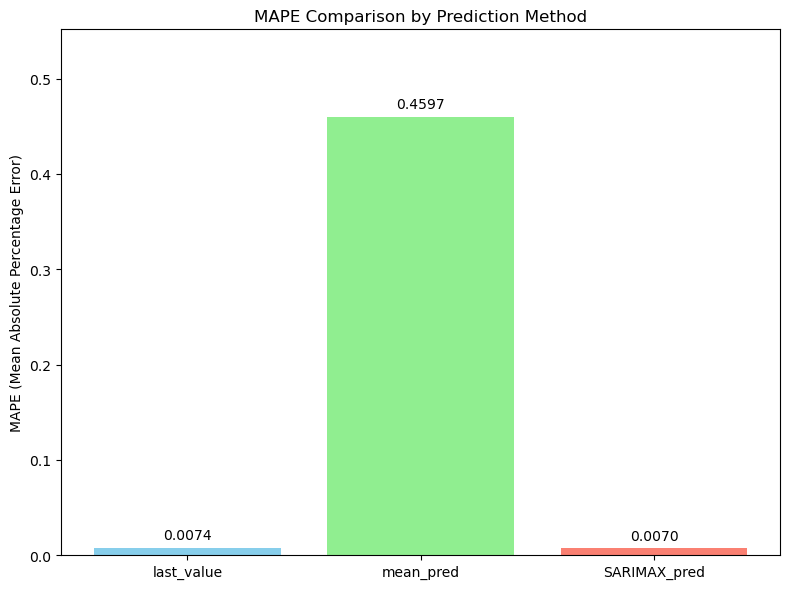

In [ ]:
#i generated this with ai btw (too lazy to plot that, i would've left it just as values shown instad of a barplot)
#MAPE
variables = ['last_value', 'mean_pred', 'SARIMAX_pred']
mape_values = [mape_last_value, mape_mean_pred, mape_SARIMAX_pred]

plt.figure(figsize=(8, 6))
plt.bar(variables, mape_values, color=['skyblue', 'lightgreen', 'salmon'])

plt.ylabel('MAPE (Mean Absolute Percentage Error)')
plt.title('MAPE Comparison by Prediction Method')
plt.ylim(0, max(mape_values) * 1.2) # Add some headroom

for i, v in enumerate(mape_values):
    plt.text(i, v + (max(mape_values)*0.02), f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [145]:
mse_last_value = mean_squared_error(pred_df['actual'], pred_df['last_value'])
mse_mean_pred = mean_squared_error(pred_df['actual'], pred_df['mean_pred'])
mse_SARIMAX_pred = mean_squared_error(pred_df['actual'], pred_df['SARIMAX_pred'])

In [147]:
val = [mse_last_value, mse_mean_pred, mse_SARIMAX_pred]
print(val)

[14267.090245428559, 36658565.21326355, 13835.126706355362]


In [138]:
pred_df[['actual', 'SARIMAX_pred']]

,actual,SARIMAX_pred
196,13366.865,13344.064035
197,13415.266,13373.512285
198,13324.600,13378.806183
199,13141.920,13327.778523
200,12925.410,13133.564454
201,12901.504,12887.743048
202,12990.341,12873.793634


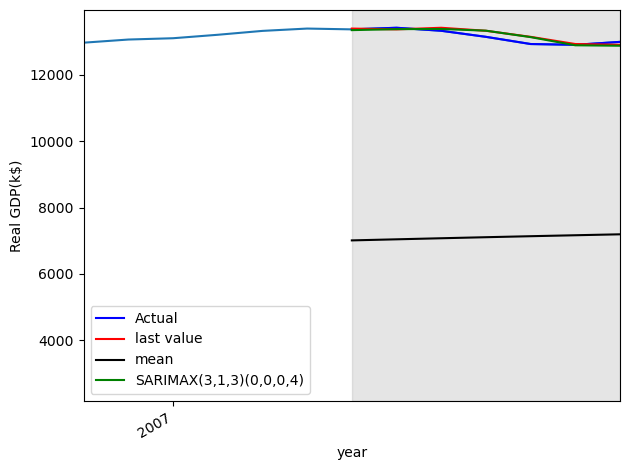

In [157]:
fig, ax = plt.subplots()

ax.plot(macro_data['realgdp'])
ax.plot(pred_df['actual'], 'b-', label='Actual')
ax.plot(pred_df['last_value'], 'r-', label='last value')
ax.plot(pred_df['mean_pred'], 'k-', label='mean')
ax.plot(pred_df['SARIMAX_pred'], 'g-', label='SARIMAX(3,1,3)(0,0,0,4)')

ax.set_xlabel('year')
ax.set_ylabel('Real GDP(k$)')
ax.axvspan(196, 202, color='grey', alpha=0.2)

plt.xticks(
    np.arange(0,208,16),
    np.arange(1959,2010,4)
)

ax.set_xlim(190,202)
fig.autofmt_xdate()
plt.legend()
plt.tight_layout()